# Level 3 - Task 1: Predictive Modeling (Classification)

## Objective

The objective of this project is to build and compare multiple classification models to predict customer churn.

The project includes data preprocessing, exploratory data analysis (EDA), feature engineering, model training, evaluation using Accuracy, Precision, Recall, F1-score, and hyperparameter tuning using GridSearchCV.

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

## Step 2: Load the Dataset

Load the customer churn dataset into a Pandas DataFrame for predictive modeling.

In [3]:
df = pd.read_csv(
    r"C:\Users\asdf\Desktop\Codeeda _Data_Analytics\Level_2\Churn Prediction Data-20260806T063928Z-1-001\Churn Prdiction Data\churn-bigml-80.csv"
)

In [4]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## Step 3: Explore the Dataset

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   float64
 15

In [6]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [8]:
df.shape

(2666, 20)

## Step 4: Check Data Quality

Identify missing values and duplicate records in the dataset.

In [9]:
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## Step 5: Encode Categorical Variables

Convert categorical columns into numerical values using Label Encoding so they can be used by machine learning models.

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## Step 6: Separate Features and Target Variable

Split the dataset into input features (X) and target variable (y).

In [12]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2666, 19)
Target Shape: (2666,)


## Step 7: Split the Dataset

Split the dataset into training and testing sets.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (2132, 19)
Testing Data: (534, 19)


## Step 8: Feature Scaling

Standardize the numerical features using StandardScaler to improve model performance.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


## Step 9: Train Logistic Regression Model

Train a Logistic Regression model using the scaled training dataset.

In [15]:
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## Step 10: Train Decision Tree Classifier

Train a Decision Tree model and make predictions on the test dataset.

In [16]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


## Step 11: Train Random Forest Classifier

Train a Random Forest model and make predictions on the test dataset.

In [17]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## Step 12: Compare Model Performance

Evaluate all three models using Accuracy, Precision, Recall, and F1-score.

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.859551,0.562500,0.227848,0.324324
1,Decision Tree,0.902622,0.684932,0.632911,0.657895
2,Random Forest,0.951311,1.000000,0.670886,0.803030


## Step 13: Identify the Best Performing Model

In [19]:
results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.951311,1.000000,0.670886,0.803030
1,Decision Tree,0.902622,0.684932,0.632911,0.657895
0,Logistic Regression,0.859551,0.562500,0.227848,0.324324


## Step 14: Hyperparameter Tuning using GridSearchCV

Optimize the Random Forest model by finding the best combination of hyperparameters.

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", round(grid.best_score_, 4))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Accuracy: 0.9522


# Step 19: Train the Best Model

In [21]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print("Best model trained successfully!")

Best model trained successfully!


# Step 20: Classification Report 

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

       False       0.95      1.00      0.97       455
        True       1.00      0.67      0.80        79

    accuracy                           0.95       534
   macro avg       0.97      0.84      0.89       534
weighted avg       0.95      0.95      0.95       534



# Step 21: Confusion Matrix

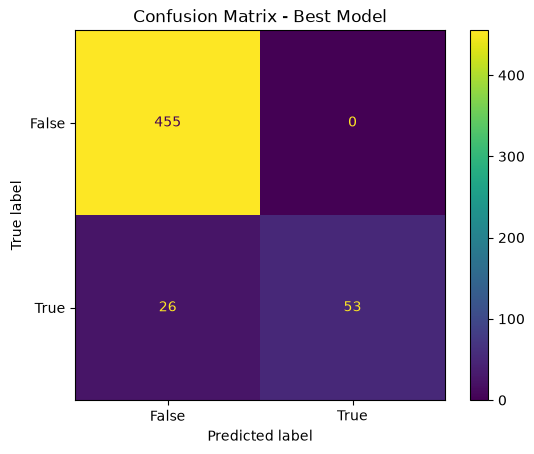

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title("Confusion Matrix - Best Model")
plt.show()

# Step 22: Feature Importance

In [24]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
6,Total day minutes,0.141488
8,Total day charge,0.121867
18,Customer service calls,0.100116
3,International plan,0.090901
11,Total eve charge,0.063653
9,Total eve minutes,0.062432
16,Total intl calls,0.056614
15,Total intl minutes,0.047054
17,Total intl charge,0.042188
12,Total night minutes,0.037129


# Step 23: Feature Importance Graph

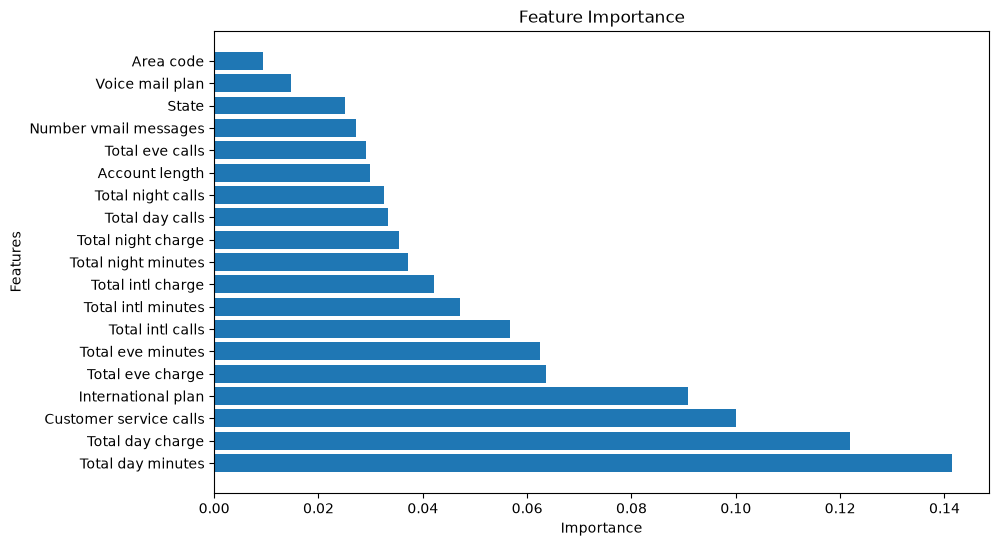

In [25]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.show()

# Step 24: Save the Best Model

In [26]:
import joblib

joblib.dump(best_model, "best_random_forest_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


# # Conclusion

In this project, multiple machine learning classification models were developed to predict customer churn.

The dataset was preprocessed by encoding categorical variables, scaling numerical features, and splitting the data into training and testing sets.

Three classification algorithms — Logistic Regression, Decision Tree, and Random Forest were trained and evaluated using Accuracy, Precision, Recall, and F1-score.

Random Forest achieved the best overall performance. Hyperparameter tuning was performed using GridSearchCV to further optimize the model.

Feature importance analysis helped identify the key factors influencing customer churn. The final optimized model was saved for future predictions.

This project demonstrates an end-to-end predictive modeling workflow, including preprocessing, model comparison, optimization, evaluation, and interpretation.